Social Media Trend Analysis 

In [1]:
# Firstly installing the required modules which are not present
# For data handling
import pandas as pd
import numpy as np
# Text cleaning and NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import emoji
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('stopwords') 
nltk.download('wordnet')       # Word definitions
nltk.download('omw-1.4')       # (Optional but recommended) Wordnet synonyms/morphology
nltk.download('punkt')         # For tokenization if you use word tokenizers later

[nltk_data] Downloading package stopwords to C:\Users\Achintya
[nltk_data]     Jha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Achintya
[nltk_data]     Jha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Achintya
[nltk_data]     Jha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Achintya
[nltk_data]     Jha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
df = pd.read_csv(r'C:/Users/Achintya Jha/OneDrive/Future_DS_01/sentimentdataset.csv')

In [3]:
df.head()
df.dropna()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [4]:
#Printing out important columns like text,timstamp,platform,likes.
df[['Text','Timestamp','Platform','Retweets','Likes']].head()


,Text,Timestamp,Platform,Retweets,Likes
0,Enjoying a beautiful day at the park! ...,2023-01-15 12:30:00,Twitter,15.0,30.0
1,Traffic was terrible this morning. ...,2023-01-15 08:45:00,Twitter,5.0,10.0
2,Just finished an amazing workout! 💪 ...,2023-01-15 15:45:00,Instagram,20.0,40.0
3,Excited about the upcoming weekend getaway! ...,2023-01-15 18:20:00,Facebook,8.0,15.0
4,Trying out a new recipe for dinner tonight. ...,2023-01-15 19:55:00,Instagram,12.0,25.0


In [5]:
#Cleaning and pre-processing data
#Storing all english stopwords in stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lower_case
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove emojis
    text = emoji.replace_emoji(text, replace='')  # Removes all emojis

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove stop words and non-alphabetic words
    text = ' '.join(word for word in text.split() if word.lower() not in stop_words and word.isalpha())

    return text
#Function for converting word to its root word
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

#Applying the defined functions on our text
df['Text'] = df['Text'].apply(clean_text)
df['Text'] = df['Text'].apply(lemmatize_text)

In [6]:
#Checking the changes occured after cleaning the text
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,enjoying beautiful day park,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,traffic terrible morning,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,finished amazing workout,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,excited upcoming weekend getaway,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,trying new recipe dinner tonight,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [11]:
#Doing NLP Analysing major topics
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
vectorizer = CountVectorizer(max_df=0.9,min_df=2,stop_words='english')
X = vectorizer.fit_transform(df['Text'])
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

#Display topwords per topic
for i, topic in enumerate(lda.components_):
    print(f"Topic {i+1}:", [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])




Topic 1: ['event', 'world', 'feeling', 'garden', 'emotion', 'personal', 'challenge', 'life', 'day', 'new']
Topic 2: ['beauty', 'nature', 'lost', 'exploring', 'whisper', 'like', 'sky', 'time', 'art', 'dream']
Topic 3: ['heart', 'gratitude', 'surprise', 'feeling', 'concert', 'moment', 'life', 'joy', 'laughter', 'friend']


In [12]:
df #Checking whether predicted sentiments match the actual ones

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,enjoying beautiful day park,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,traffic terrible morning,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,finished amazing workout,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,excited upcoming weekend getaway,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,trying new recipe dinner tonight,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,collaborating science project received recogni...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,attending surprise birthday party organized fr...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,successfully fundraising school charity initia...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,participating multicultural festival celebrati...,Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


<Axes: xlabel='Timestamp'>

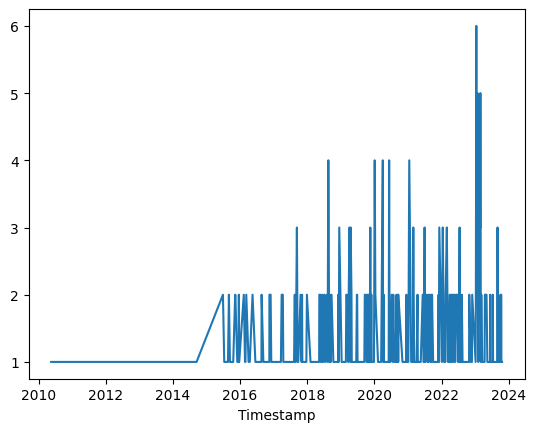

In [11]:
#Trend Analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.date
trend = df.groupby('Timestamp').size()
trend.plot(kind='line')

In [12]:
#Sentiment Analysis check by text blob
def get_sentiment(text):
    text = df['Text']
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity>0:
        return 'positive'
    if polarity<0:
        return 'negative'
    if polarity == 0:
        return 'neutral'
df['predicted_sentiment'] = df['Text'].apply(get_sentiment)

